In [1]:
import numpy as np
import h5py
import scipp as sc

In [2]:
file='gamma_0/mccode.h5'
#file='/Users/christianbeck/Documents/mccode.h5'


# Read the specific dataset from the HDF5 file into a NumPy array
with h5py.File(file, 'r') as hdf5_file:
    dataset_name = '/entry1/data/detector_inner_list_p_th_L_t_y/events' # Specify the dataset name
    data_banana = hdf5_file[dataset_name][:]
    Y=np.array(0)
    Z=np.array(0)
    T=np.array(0)
    for hi in range(1,49):
        for hit,tb in enumerate(['t','b']):
            dataset_tube = f'/entry1/data/tube{hi}{tb}_list_p_L_t_y/events' # Specify the dataset name
            try:
                data_tube = hdf5_file[dataset_tube][:]
                if hit==1:
                    #print(data_tube)
                    #data_tube=np.transpose(np.array([data_tube]))
                    print(data_tube[:,3])
                    print(dataset_tube)
                yi=data_tube[:,3]
                Y=np.append(Y,yi+0.15-hit*0.3)
                Z=np.append(Z,data_tube[:,0])
                T=np.append(T,hi*yi/yi)
            except:
                pass
            #Y=np.array(Y,yi)
            #Z=np.array(Z,)
            #T=np.array(T,hi*yi/yi)

[ 2.44157031e-02 -6.03398622e-02  3.91987324e-02  5.57080825e-02
  3.80364242e-02 -2.54182181e-02 -2.13724749e-02  5.48497773e-02
 -5.98318379e-02  2.41567565e-02  2.94671235e-02  7.35087988e-02
  5.17240010e-02 -1.51320667e-02  4.38114184e-02  7.31273890e-03
 -1.21128621e-02  5.45214811e-02  1.15660365e-02 -2.16508782e-02
  9.26632630e-03  1.82339596e-02 -5.62068745e-02  4.39581637e-02
  2.09551622e-02 -4.11244076e-02 -4.78493592e-02 -1.49383602e-02
 -6.22314088e-02 -3.61906423e-02  1.68633174e-02 -3.56967216e-03
 -8.12564015e-03 -6.44107702e-02 -4.43222266e-02  8.24968280e-03
  1.80373879e-02 -1.77898772e-03  6.13024399e-02 -1.11963137e-02
  2.82070590e-02  4.64816098e-02 -3.44369337e-02 -1.71596856e-02
  2.06758762e-03  4.86714780e-03 -3.32451895e-03  4.32762922e-03
 -5.64035513e-02  3.07755589e-02 -4.48921978e-02 -1.68627702e-02
 -1.77955877e-02 -4.00580490e-02  5.40545462e-02 -3.44557311e-02
  5.14393652e-02 -4.40448465e-02 -1.53953507e-02  6.51617548e-02
  2.07910664e-02 -3.89808

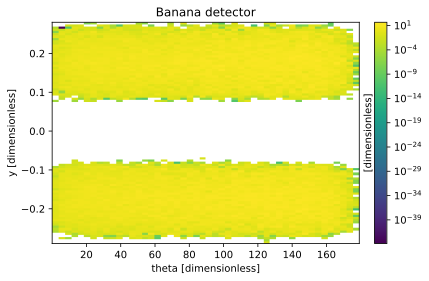

In [3]:
x=sc.array(values=data_banana[:,1],dims=['event'],unit='1')
y=sc.array(values=data_banana[:,4],dims=['event'],unit='1')
z=sc.array(values=data_banana[:,0],dims=['event'],unit='1')
da=sc.DataArray(z,coords={'theta':x,'y':y})
dab=da.bin(y=100,theta=48)
dab.hist().plot(norm='log',title='Banana detector')

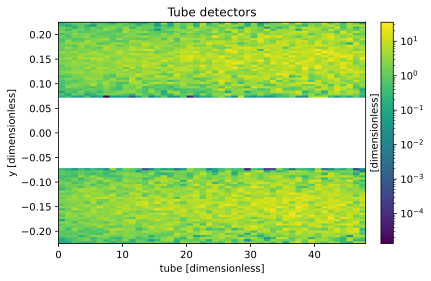

In [4]:
Ts=sc.array(values=T,dims=['event'],unit='1')
Ys=sc.array(values=Y,dims=['event'],unit='1')
Zs=sc.array(values=Z,dims=['event'],unit='1')
dat=sc.DataArray(Zs,coords={'tube':Ts,'y':Ys})
datb=dat.bin(y=100,tube=48)
datb.hist().plot(norm='log',title='Tube detectors')

In [5]:
T,Z,Y

(array([ 0.,  1.,  1., ..., 48., 48., 48.], shape=(129203,)),
 array([0.00000000e+00, 5.16088300e-11, 1.91242663e-07, ...,
        3.55799869e-07, 5.86516714e-02, 4.20320695e-05], shape=(129203,)),
 array([ 0.        ,  0.09185211,  0.17161833, ..., -0.20126071,
        -0.13042084, -0.15474412], shape=(129203,)))